In [9]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from scipy.optimize import curve_fit
from matplotlib import cm
from scipy import special

from matplotlib.pyplot import MultipleLocator
from matplotlib.ticker import MultipleLocator,FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [10]:
SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

plt.rc('font', size=20)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams['legend.title_fontsize'] = SMALL_SIZE - 1

ml = MultipleLocator(2)

In [31]:
def getRootDataAirElectrons(filename, save_filename="test", nPrimaries=1e8, particle_id=5):
    # Open the ROOT file
    file = uproot.open(filename)
    
    # Access the 'Gamma' ntuple (usually under "Gamma" or "ntuple" inside the file)
    # List all keys to be sure
    # print("Available keys:", file.keys())

    # Access the TTree for Gamma
    gamma_tree = file["Gamma;1"]  # If needed, replace with actual name from file.keys()

    # Load the x, y, energy arrays
    x = gamma_tree["x"].array(library="np")
    y = gamma_tree["y"].array(library="np")
    energy = gamma_tree["energy"].array(library="np")
    particle = gamma_tree["particle"].array(library="np")

    filter_electrons = (particle == particle_id)

    x = x[filter_electrons]
    y = y[filter_electrons]
    energy = energy[filter_electrons]

    # Convert x, y from mm to micrometers
    x_um = x
    y_um = y

    if particle_id == 5:
        aux_text = 'Electron'
    elif (particle_id == 1):
        aux_text = 'Gamma'
    elif (particle_id == 9):
        aux_text = 'Positron'

    if len(x != energy):
        #np.save('Kapton50um+Air_x.npy', x_um)
        #np.save(f'{test}_y.npy', y_um)
        np.savez_compressed(f'{save_filename}.npz', x=x, y=y, e=energy)
    
        energy_idx = (energy > 0)
        
        # plot
        cols = [cm.plasma(r) for r in np.linspace(0.1, 0.9 , 4)]
        lw_user=1.2
    
        fig, axes1 = plt.subplots(1,2, figsize=(18, 6))
        axes = iter(np.ravel(axes1))
    
        # Gamma scattering
        ax = next(axes)
        h = ax.hist2d(x_um[energy_idx], y_um[energy_idx], bins=100, range=[[-300, 300], [-300, 300]], cmap="viridis", norm=LogNorm())
        fig.colorbar(h[3], ax=ax, label="Counts")
    
        ax.xaxis.set_major_locator(MultipleLocator(100))
        ax.xaxis.set_minor_locator(MultipleLocator(50))
        ax.yaxis.set_major_locator(MultipleLocator(100))
        ax.yaxis.set_minor_locator(MultipleLocator(50))
        ax.set_ylabel("y [um]")
        ax.set_xlabel("x [um]")
    
        ax.xaxis.grid(which="major", alpha=1)
        ax.xaxis.grid(which="minor", alpha=0.3)
        ax.yaxis.grid(which="major", alpha=1)
        ax.yaxis.grid(which="minor", alpha=0.3)
        ax.set_ylim(-300, 300)
        ax.set_xlim(-300, 300)
        
        
        ax = next(axes)
        plt.hist(energy[energy_idx], bins=120, range=(0, 12), histtype='stepfilled', color='skyblue', edgecolor='black')
        ax.set_xlabel("Energy [keV]")
        ax.set_yscale('log')
        ax.set_ylabel("Particles")
        ax.set_title(f"{aux_text} energy spectrum")
        ax.grid(True, alpha=0.3)
    
        fig.tight_layout()
        plt.show()
        fig.savefig("figures/" + save_filename + ".png", bbox_inches="tight", dpi=300)
        fig.savefig("figures/" + save_filename + ".pdf", bbox_inches="tight", dpi=300)
    else:
        print("No Electrons")
    
    # Statistics
    n_particles = len(energy)
    print(f"Number of particles = {n_particles:d}")
    if particle_id == 1:
        transmission = n_particles/nPrimaries * 100 # in percent
        print(f"Transmission X-rays = {transmission:.1f} \%")
    

In [6]:
def getRootDataAir(filename, save_filename="test", nPrimaries=1e8):
    # Open the ROOT file
    file = uproot.open(filename)
    
    # Access the 'Gamma' ntuple (usually under "Gamma" or "ntuple" inside the file)
    # List all keys to be sure
    # print("Available keys:", file.keys())

    # Access the TTree for Gamma
    gamma_tree = file["Gamma;1"]  # If needed, replace with actual name from file.keys()

    # Load the x, y, energy arrays
    x = gamma_tree["x"].array(library="np")
    y = gamma_tree["y"].array(library="np")
    energy = gamma_tree["energy"].array(library="np")

    # Convert x, y from mm to micrometers
    x_um = x
    y_um = y

    #np.save('Kapton50um+Air_x.npy', x_um)
    #np.save(f'{test}_y.npy', y_um)
    np.savez_compressed(f'{save_filename}.npz', x=x, y=y, e=energy)

    energy_idx = (energy > 0)
    
    # plot
    cols = [cm.plasma(r) for r in np.linspace(0.1, 0.9 , 4)]
    lw_user=1.2

    fig, axes1 = plt.subplots(1,2, figsize=(18, 6))
    axes = iter(np.ravel(axes1))

    # Gamma scattering
    ax = next(axes)
    h = ax.hist2d(x_um[energy_idx], y_um[energy_idx], bins=100, range=[[-300, 300], [-300, 300]], cmap="viridis", norm=LogNorm())
    fig.colorbar(h[3], ax=ax, label="Counts")

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.xaxis.set_minor_locator(MultipleLocator(50))
    ax.yaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_minor_locator(MultipleLocator(50))
    ax.set_ylabel("y [um]")
    ax.set_xlabel("x [um]")

    ax.xaxis.grid(which="major", alpha=1)
    ax.xaxis.grid(which="minor", alpha=0.3)
    ax.yaxis.grid(which="major", alpha=1)
    ax.yaxis.grid(which="minor", alpha=0.3)
    ax.set_ylim(-300, 300)
    ax.set_xlim(-300, 300)
    
    
    ax = next(axes)
    plt.hist(energy[energy_idx], bins=120, range=(0, 12), histtype='stepfilled', color='skyblue', edgecolor='black')
    ax.set_xlabel("Energy [keV]")
    ax.set_yscale('log')
    ax.set_ylabel("Particles")
    ax.set_title("Gamma energy spectrum")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()
    fig.savefig("figures/" + save_filename + ".png", bbox_inches="tight", dpi=300)
    fig.savefig("figures/" + save_filename + ".pdf", bbox_inches="tight", dpi=300)
    
    # Statistics
    n_particles = len(energy)
    print(f"Number of particles = {n_particles:d}")
    transmission = n_particles/nPrimaries * 100 # in percent
    print(f"Transmission X-rays = {transmission:.1f} \%")
    

In [7]:
def getRootDataVacuum(filename, save_filename="test", nPrimaries=1e8):
    # Open the ROOT file
    file = uproot.open(filename)
    
    # Access the 'Gamma' ntuple (usually under "Gamma" or "ntuple" inside the file)
    # List all keys to be sure
    # print("Available keys:", file.keys())

    # Access the TTree for Gamma
    gamma_tree = file["Gamma;1"]  # If needed, replace with actual name from file.keys()

    # Load the x, y, energy arrays
    x = gamma_tree["x"].array(library="np")
    y = gamma_tree["y"].array(library="np")
    energy = gamma_tree["energy"].array(library="np")

    # Convert x, y from mm to micrometers
    x_um = x
    y_um = y

    energy_idx = (energy > 0)
    np.savez_compressed(f'{save_filename}.npz', x=x, y=y, e=energy)
    
    # plot
    cols = [cm.plasma(r) for r in np.linspace(0.1, 0.9 , 4)]
    lw_user=1.2

    fig, axes1 = plt.subplots(1,2, figsize=(18, 6))
    axes = iter(np.ravel(axes1))

    # Gamma scattering
    ax = next(axes)
    h = ax.hist2d(x_um[energy_idx], y_um[energy_idx], bins=100, range=[[-5, 5], [-5, 5]], cmap="viridis", norm=LogNorm())
    fig.colorbar(h[3], ax=ax, label="Counts")

    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(.1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(.1))
    ax.set_ylabel("y [µm]")
    ax.set_xlabel("x [µm]")

    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(.25))

    ax.xaxis.grid(which="major", alpha=1)
    ax.xaxis.grid(which="minor", alpha=0.3)
    ax.yaxis.grid(which="major", alpha=1)
    ax.yaxis.grid(which="minor", alpha=0.3)
    ax.set_ylim(-5, 5)
    ax.set_xlim(-5, 5)
    
    
    ax = next(axes)
    plt.hist(energy, bins=120, range=(0, 12), histtype='stepfilled', color='skyblue', edgecolor='black')
    ax.set_xlabel("Energy [keV]")
    ax.set_yscale('log')
    ax.set_ylabel("Particles")
    ax.set_title("Gamma energy spectrum")
    ax.grid(True, alpha=0.3)

    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(.25))

    fig.tight_layout()
    plt.show()
    fig.savefig("figures/" + save_filename + ".png", bbox_inches="tight", dpi=300)
    fig.savefig("figures/" + save_filename + ".pdf", bbox_inches="tight", dpi=300)
    
    # Statistics
    n_particles = len(energy)
    print(f"Number of particles = {n_particles:d}")
    transmission = n_particles/nPrimaries * 100 # in percent
    print(f"Transmission X-rays = {transmission:.1f} \%")
    

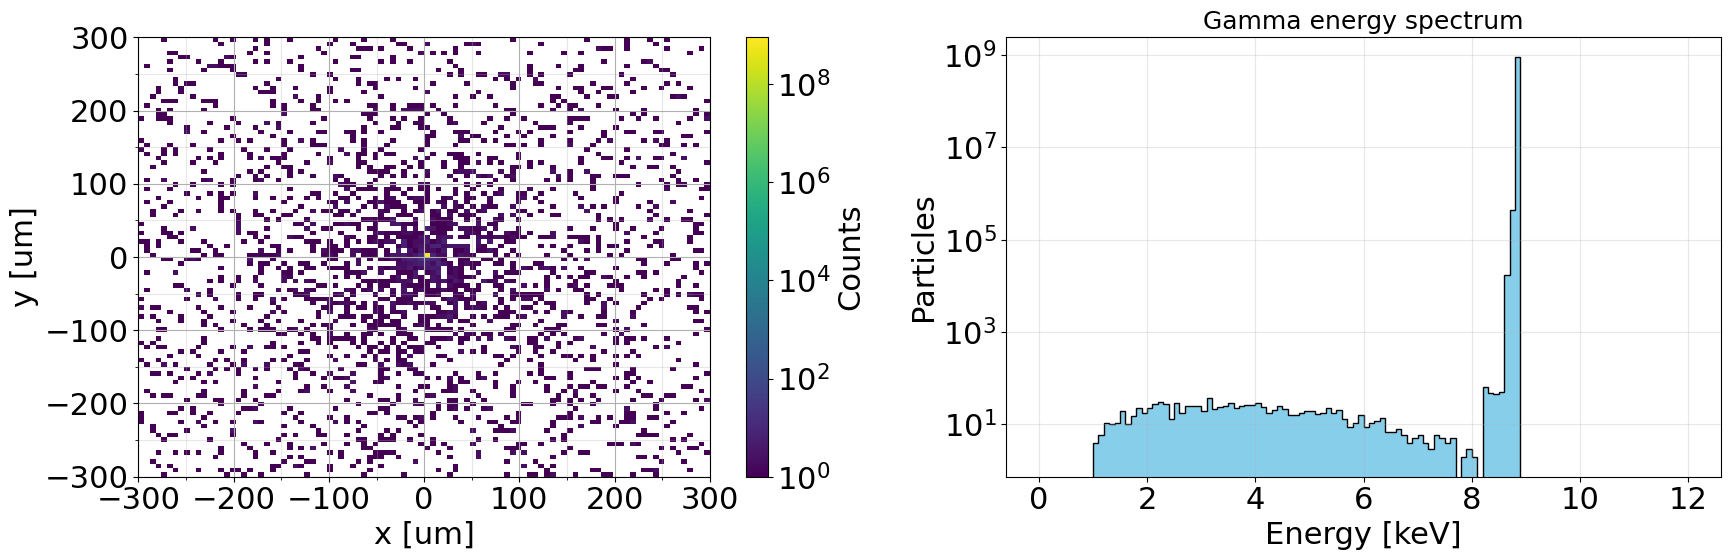

Number of particles = 885606096
Transmission X-rays = 44.3 \%
CPU times: user 4min 26s, sys: 54.5 s, total: 5min 20s
Wall time: 5min 16s


In [167]:
%%time
getRootDataAir('Pol01/build-kapton+air_stats/compton.root', 
                save_filename='xray_Primaries5e9_50umKapton_Air_stats',
                nPrimaries=20e8)

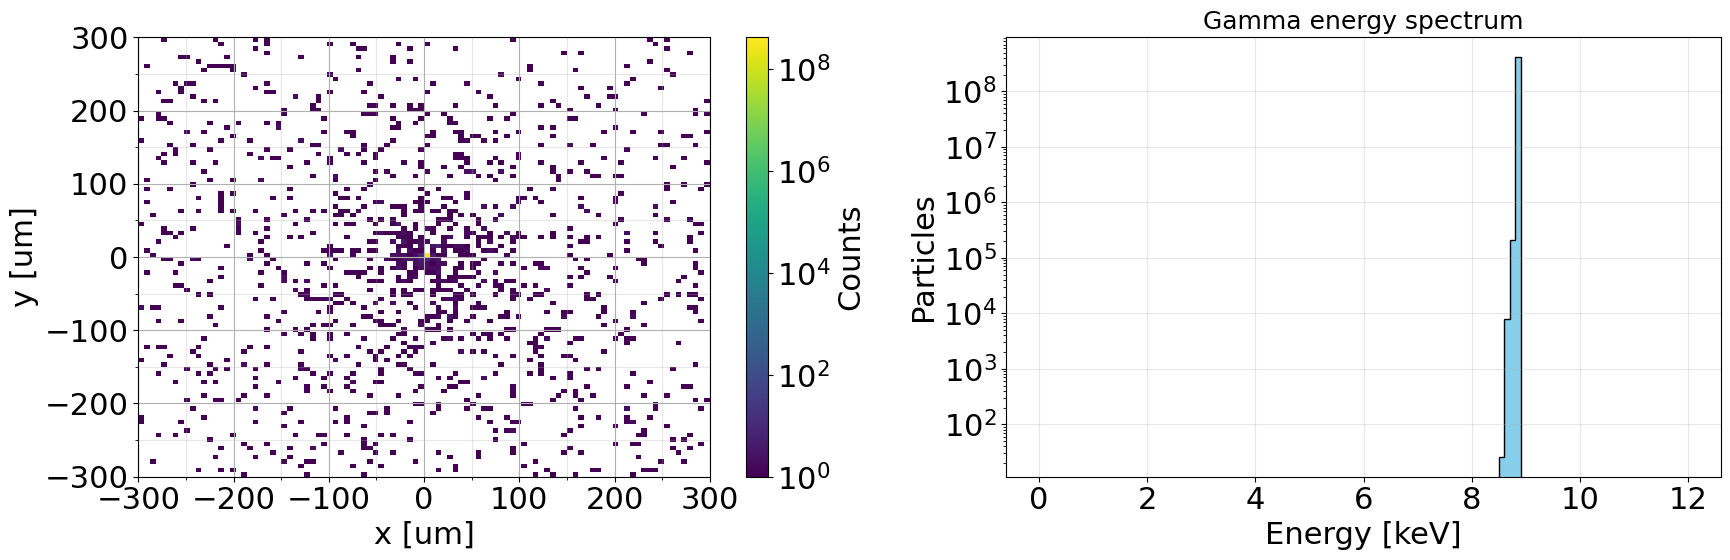

Number of particles = 412388932
Transmission X-rays = 41.2 \%


In [155]:
getRootDataAir('Pol01/build-kapton+air_stats/xray_Primaries1e9_50umKapton_Air.root', 
                save_filename='xray_Primaries1e9_50umKapton_Air_stats',
                nPrimaries=10e8)

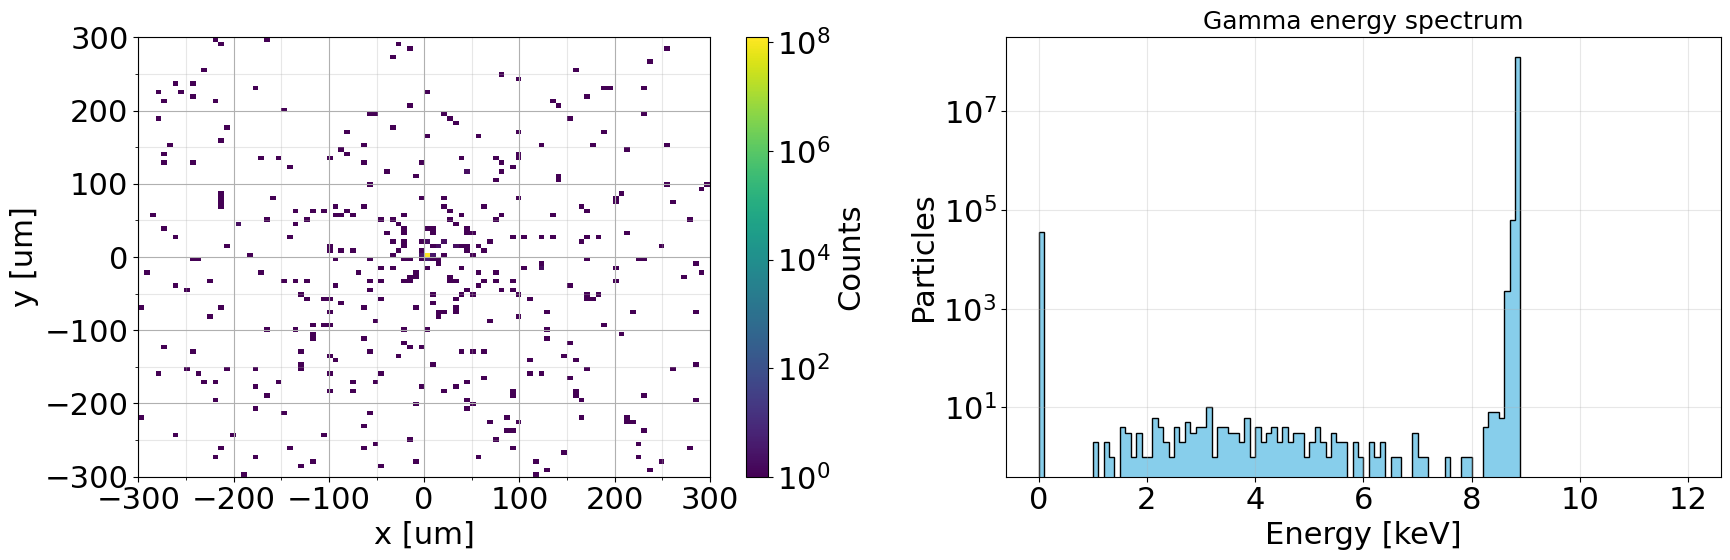

Number of particles = 123712956
Transmission X-rays = 41.2 \%


In [139]:
getRootDataAir('Pol01/build-kapton+air_stats/xray_Primaries3e8_50umKapton_Air.root', 
                save_filename='xray_Primaries3e8_50umKapton_Air',
                nPrimaries=3e8)

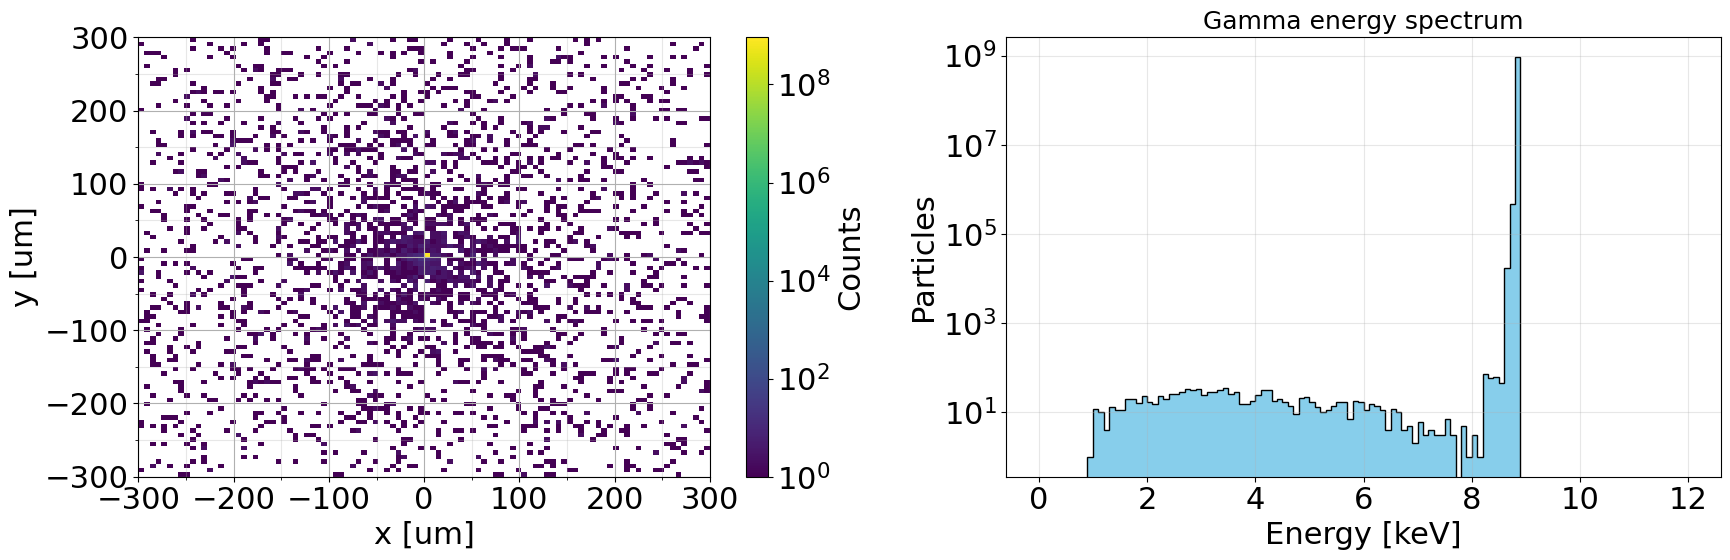

Number of particles = 913491063
Transmission X-rays = 18.3 \%


In [166]:
getRootDataAir('Pol01/build-air/compton.root', 
                save_filename='xray_Primaries5e9_onlyAir_stats',
                nPrimaries=50e8)

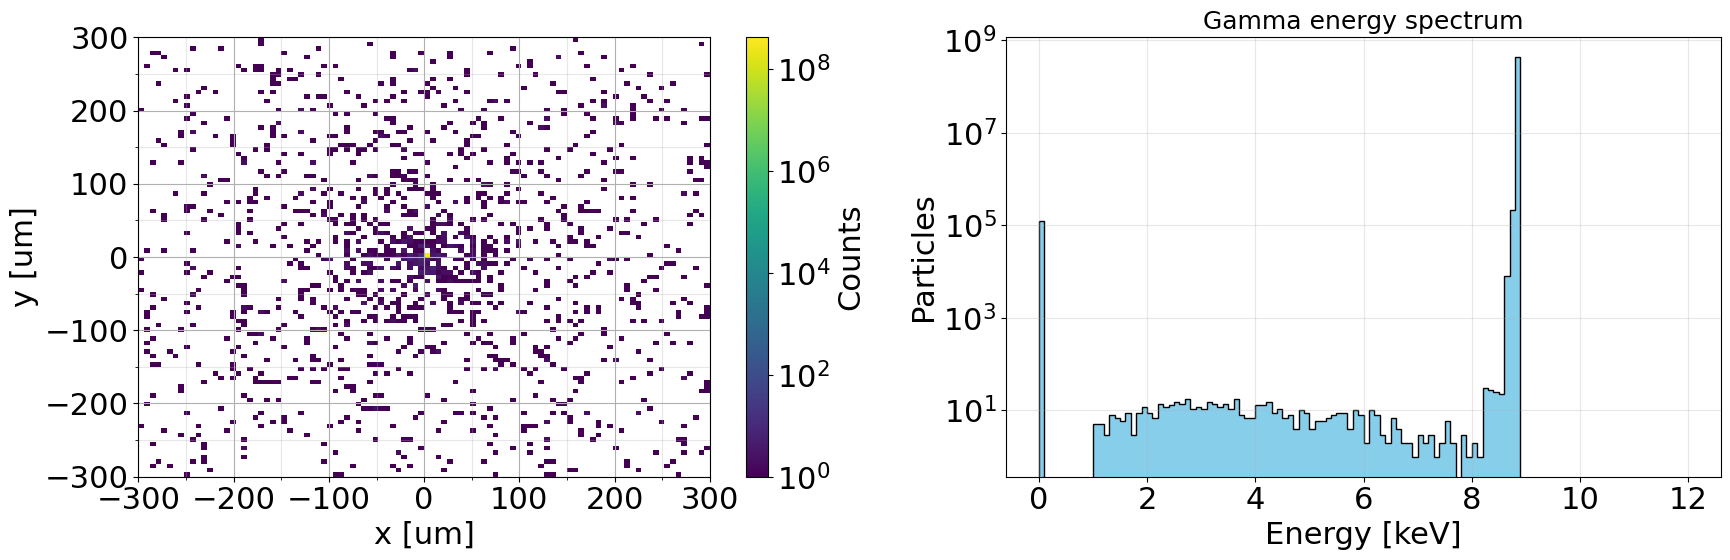

Number of particles = 425352601
Transmission X-rays = 42.5 \%


In [140]:
getRootDataAir('Pol01/build-air/xray_Primaries1e9_onlyAir.root', 
                save_filename='xray_Primaries1e9_onlyAir_stats',
                nPrimaries=10e8)

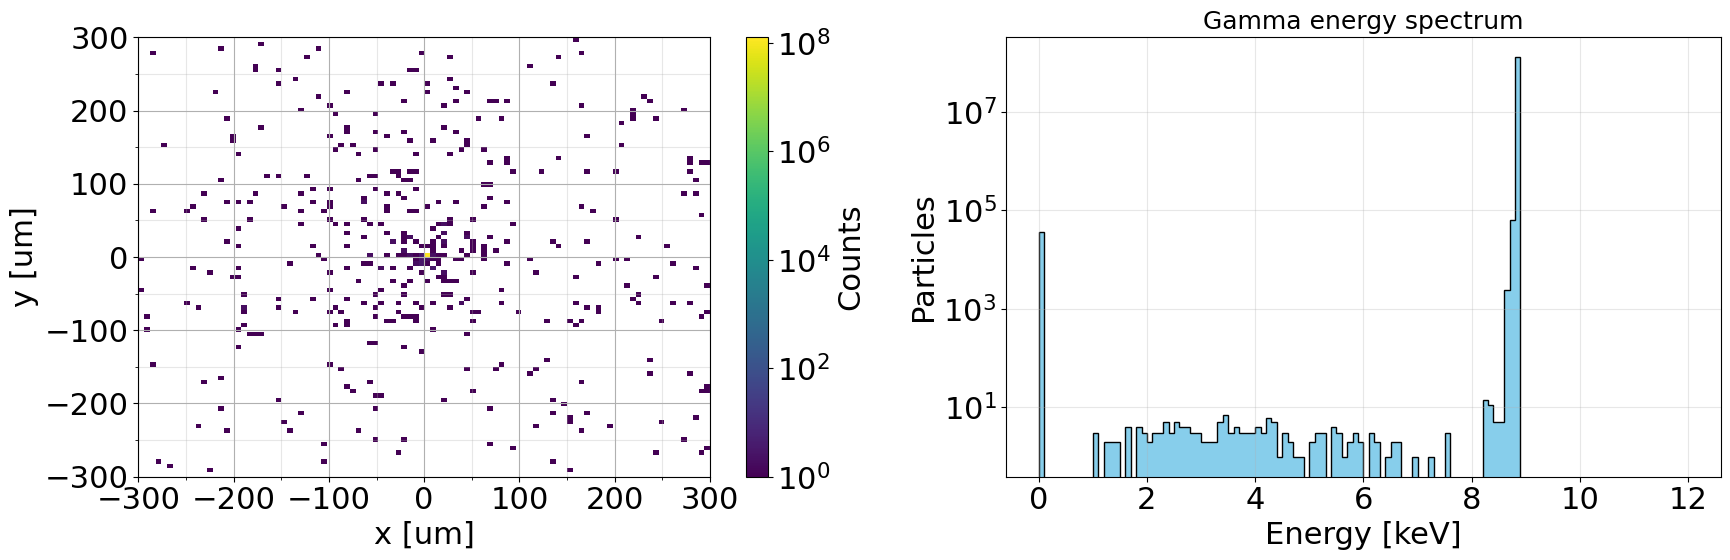

Number of particles = 127606093
Transmission X-rays = 42.5 \%


In [141]:
getRootDataAir('Pol01/build-air/xray_Primaries3e8_onlyAir.root', 
                save_filename='xray_Primaries3e8_onlyAir',
                nPrimaries=3e8)

### New sims with only 10 cm Air

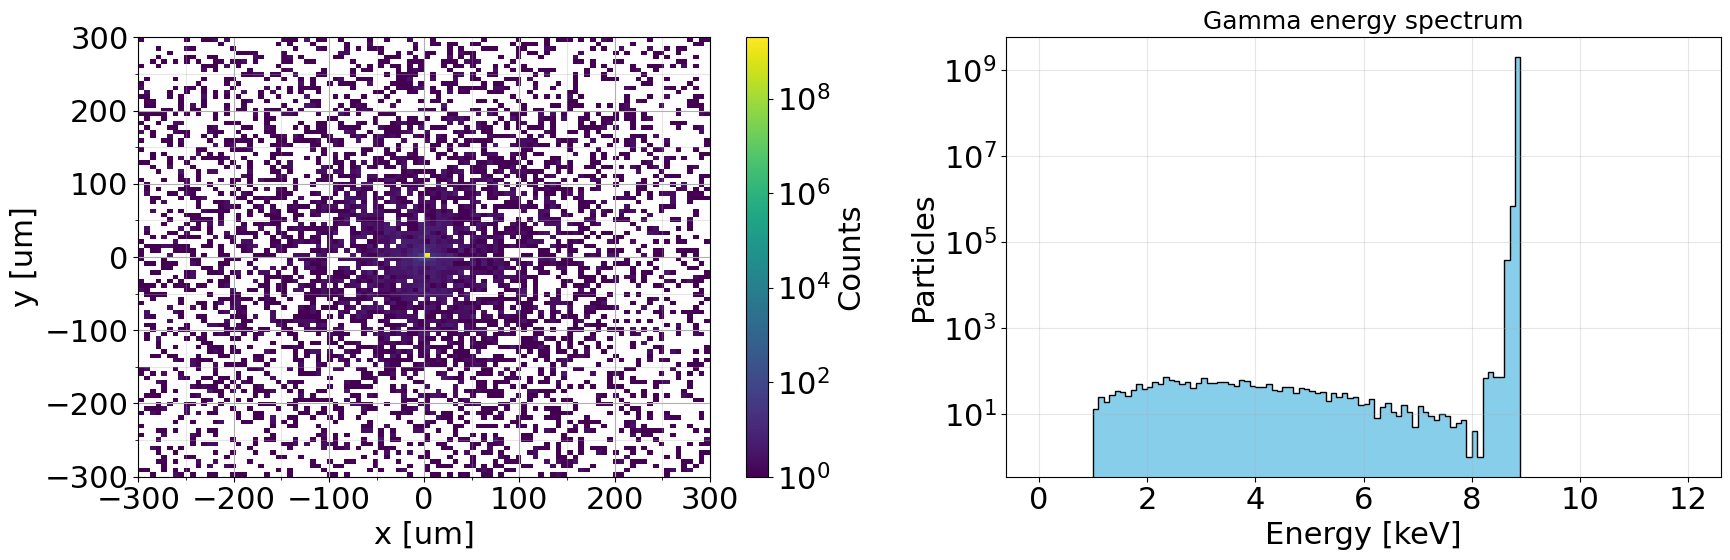

Number of particles = 1972669069
Transmission X-rays = 98.6 \%
CPU times: user 10min 9s, sys: 3min 4s, total: 13min 13s
Wall time: 13min 36s


In [168]:
%%time
getRootDataAir('Pol01/build-10cm-noKapton/compton.root', 
                save_filename='xray_Primaries5e9_onlyAir_stats',
                nPrimaries=20e8)

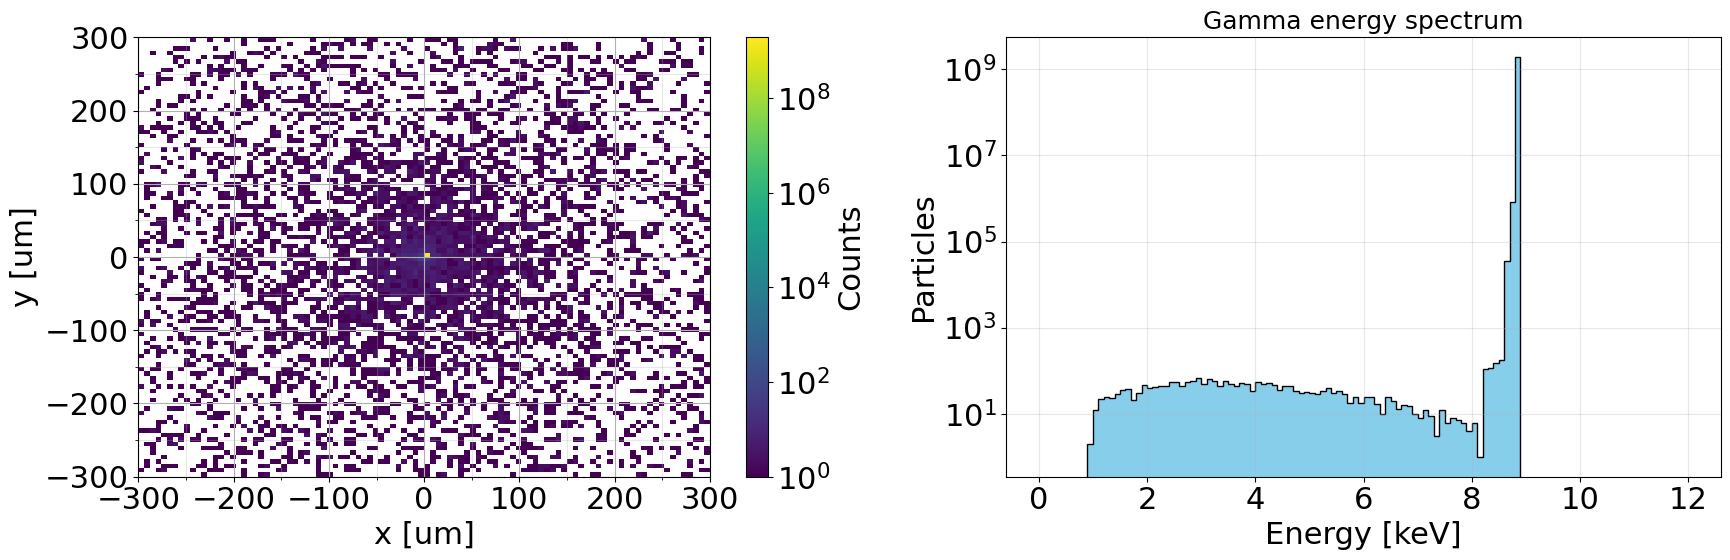

Number of particles = 1912659125
Transmission X-rays = 95.6 \%
CPU times: user 9min 55s, sys: 2min 26s, total: 12min 22s
Wall time: 12min 17s


In [169]:
%%time
getRootDataAir('Pol01/build-10cm/compton.root', 
                save_filename='xray_Primaries5e9_50umKapton_stats',
                nPrimaries=20e8)

## Vacuum

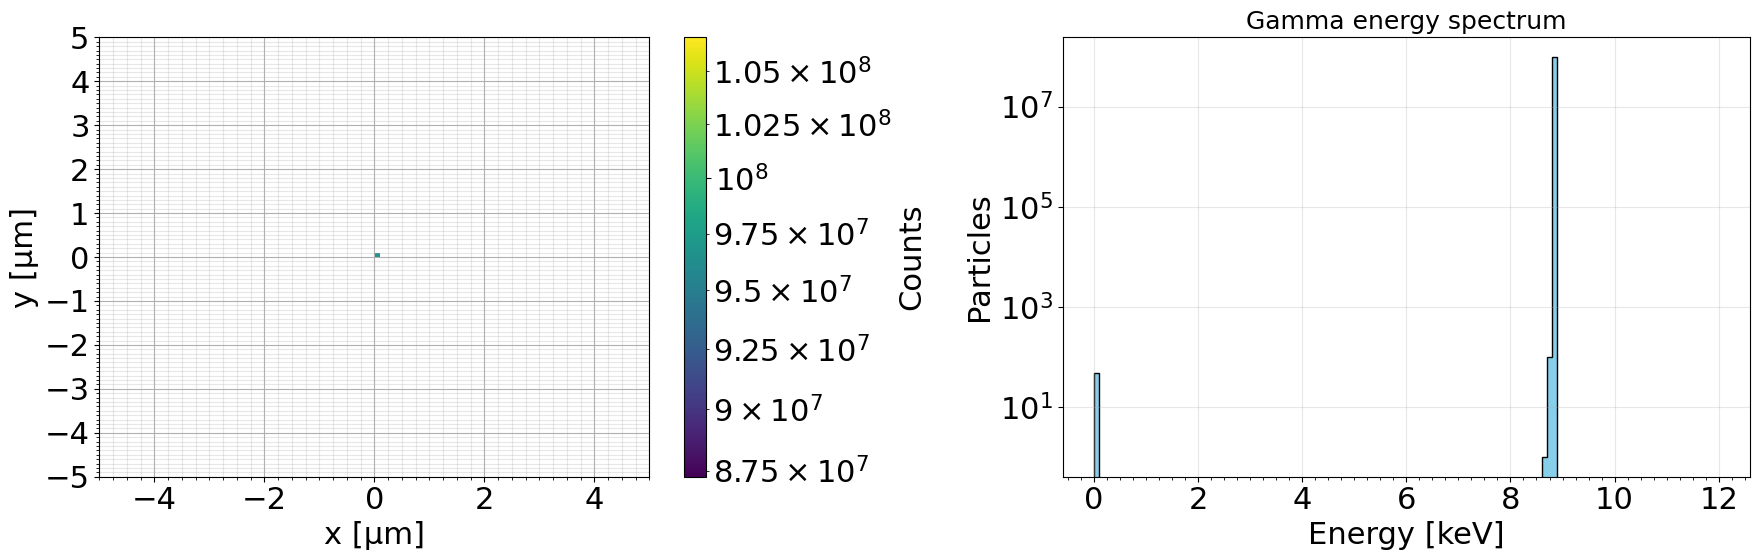

Number of particles = 96948561
Transmission X-rays = 96.9 \%


In [164]:
getRootDataVacuum('Pol01/build/xray_Primaries1e8_50umKapton_Vacuum.root', 
                  save_filename='xray_Primaries1e8_50umKapton_Vacuum',
                  nPrimaries=1e8)

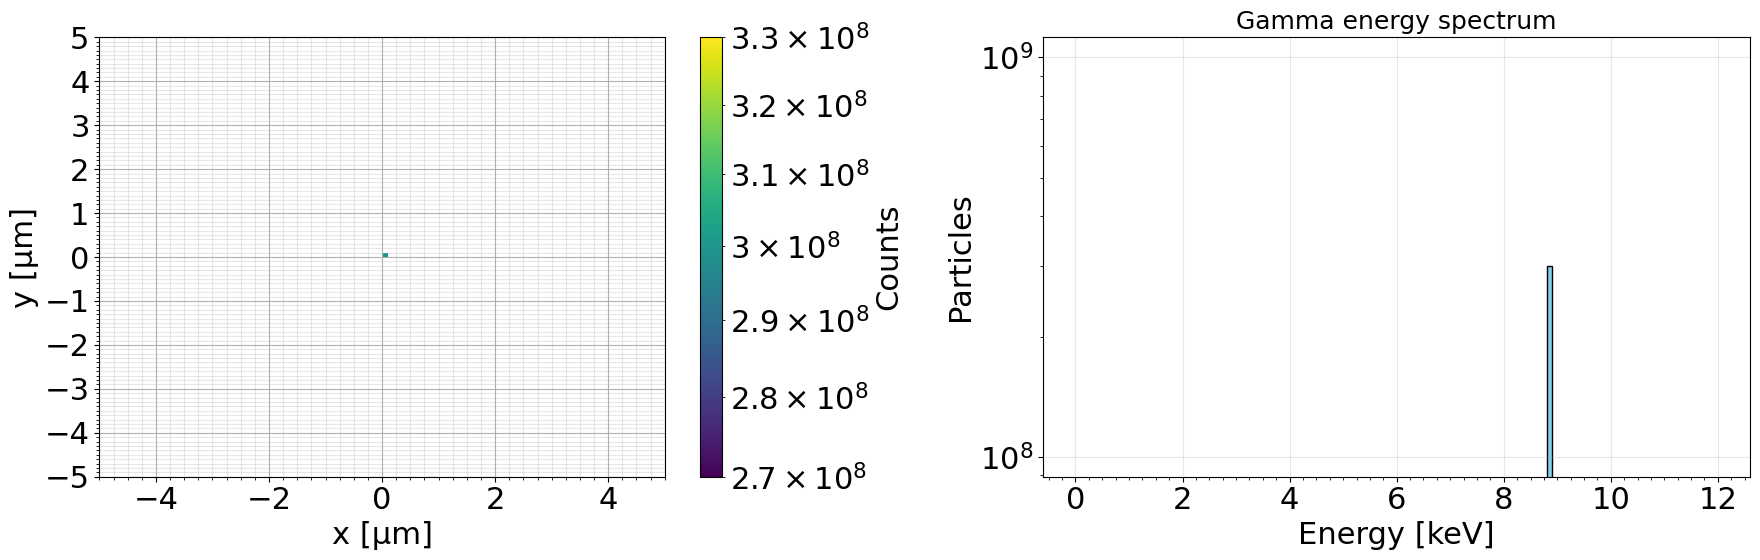

Number of particles = 300000000
Transmission X-rays = 100.0 \%


In [165]:
getRootDataVacuum('Pol01/build-vacuum/compton.root', 
                  save_filename='xray_Primaries3e8_onlyVacuum',
                  nPrimaries=3e8)

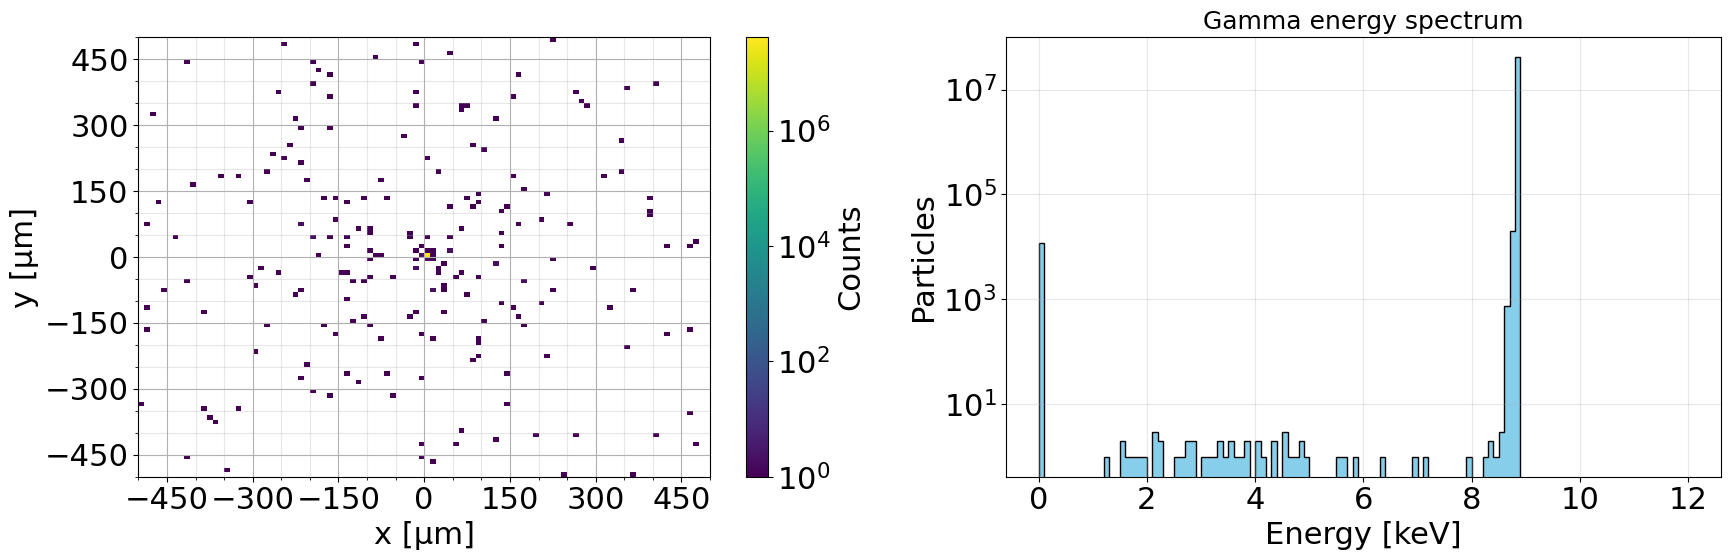

Number of particles = 41244354
Transmission X-rays = 41.2 \%


In [62]:
getRootDataAir('Pol01/build/xray_Primaries1e8_50umKapton_Air.root', 
               save_filename='xray_Primaries1e8_50umKapton_Air')

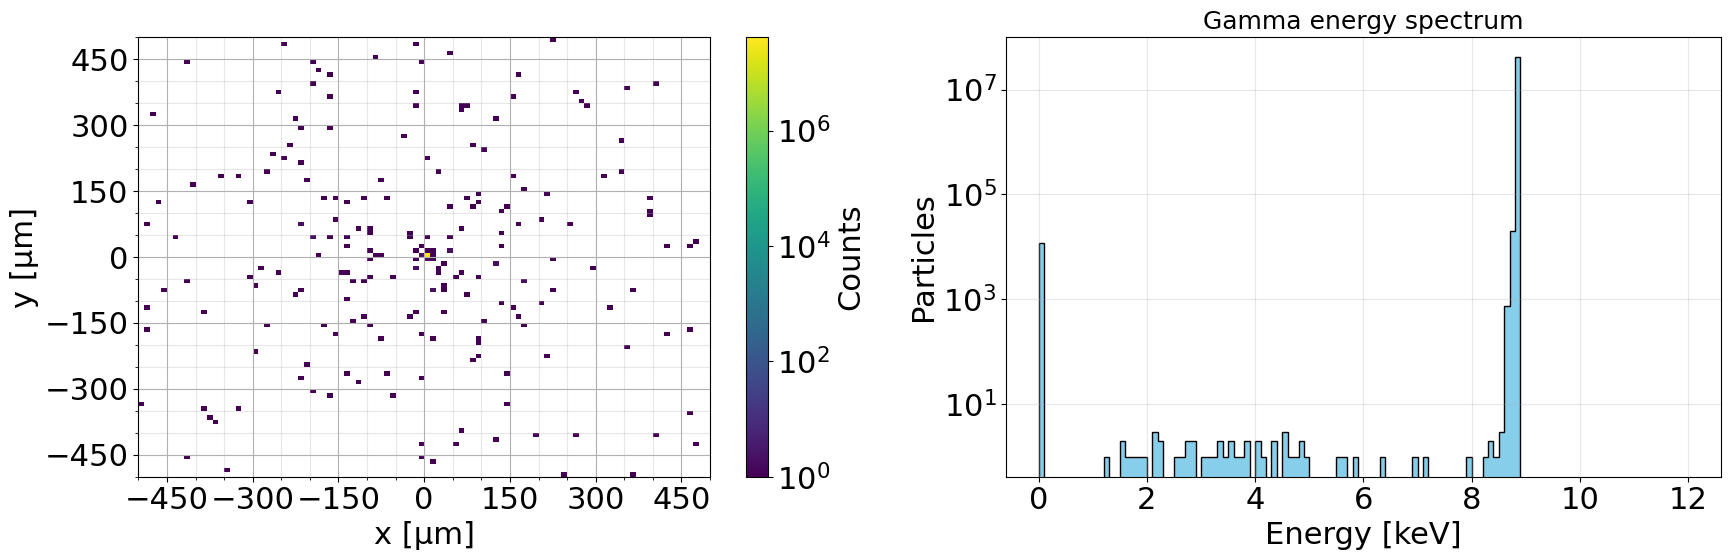

Number of particles = 41244354
Transmission X-rays = 41.2 \%


In [66]:
getRootDataAir('Pol01/build/xray_Primaries1e8_50umKapton_Air_2.root', 
               save_filename='xray_Primaries1e8_50umKapton_Air_2')

# New sims with 1 meter Air but also recording other particles

**Particle IDs:**
* 1: Gammas/X-rays
* 5: Electrons
* 9: Positrons

## With Kapton

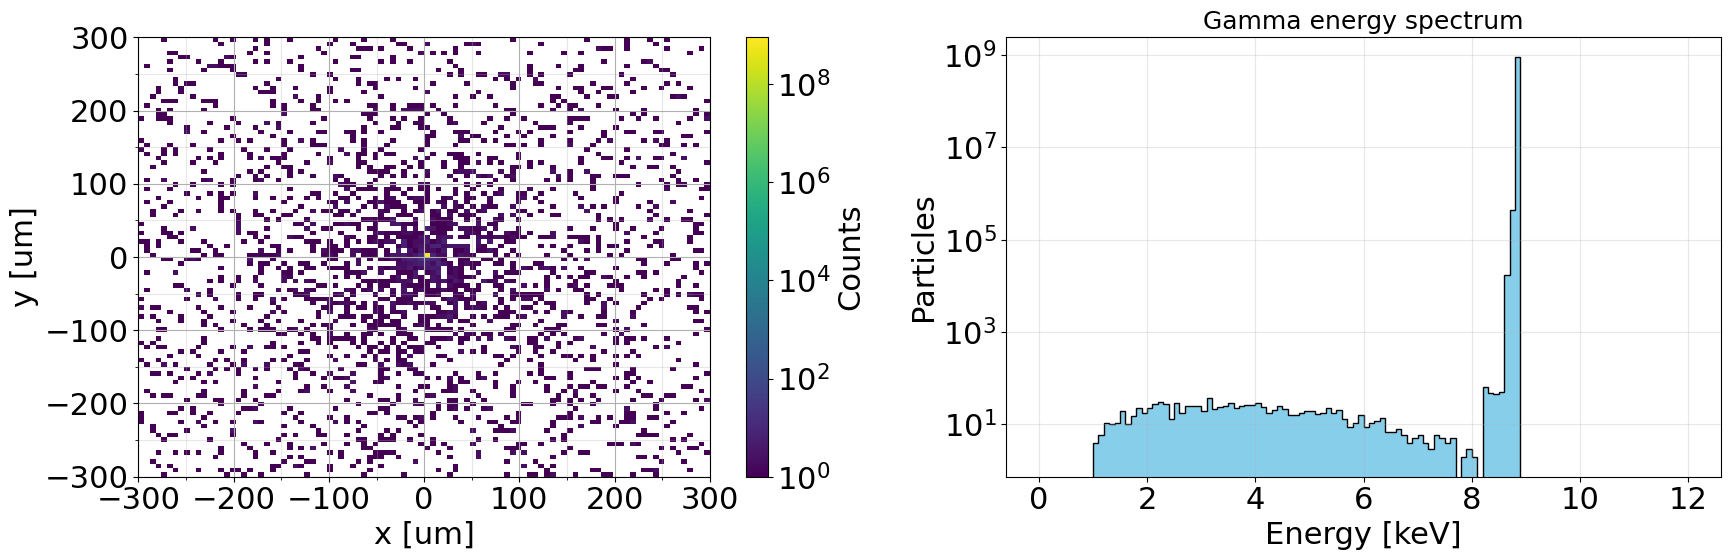

Number of particles = 885352180
Transmission X-rays = 421.6 \%


In [36]:
# Gamma
getRootDataAirElectrons('Pol01/build-10cm-electrons/compton.root', 
                save_filename='xray_Primaries2.1e9_50umKapton_1mAir_x-rays',
                particle_id = 1,
                nPrimaries=2.100e9)

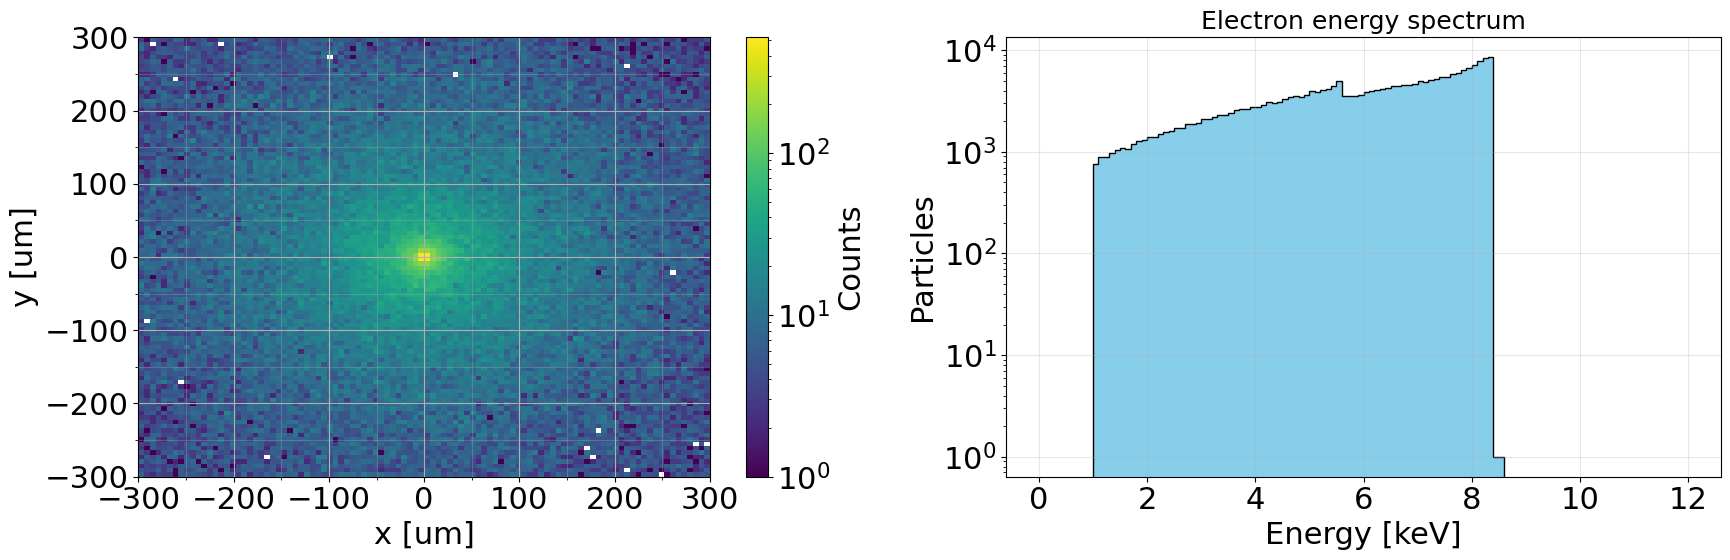

Number of particles = 253916


In [37]:
# Electrons
getRootDataAirElectrons('Pol01/build-10cm-electrons/compton.root', 
                save_filename='xray_Primaries2.1e9_50umKapton_1mAir_electrons',
                particle_id = 5,
                nPrimaries=2.100e9)

## Without Kapton

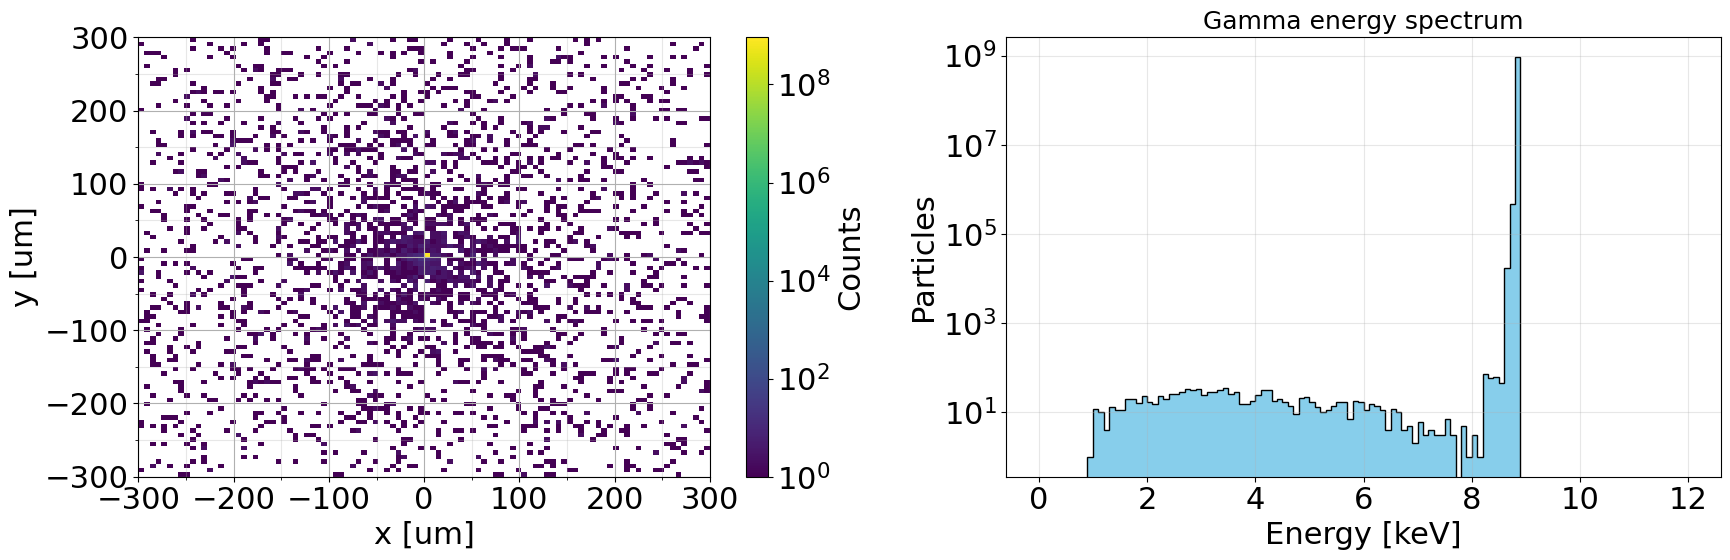

Number of particles = 913228108
Transmission X-rays = 434.9 \%


In [38]:
# Gamma
getRootDataAirElectrons('Pol01/build-10cm-electrons-noKapton/compton.root', 
                save_filename='xray_Primaries2.1e9_50um-NoKapton_1mAir_x-rays',
                particle_id = 1,
                nPrimaries=2.100e9)

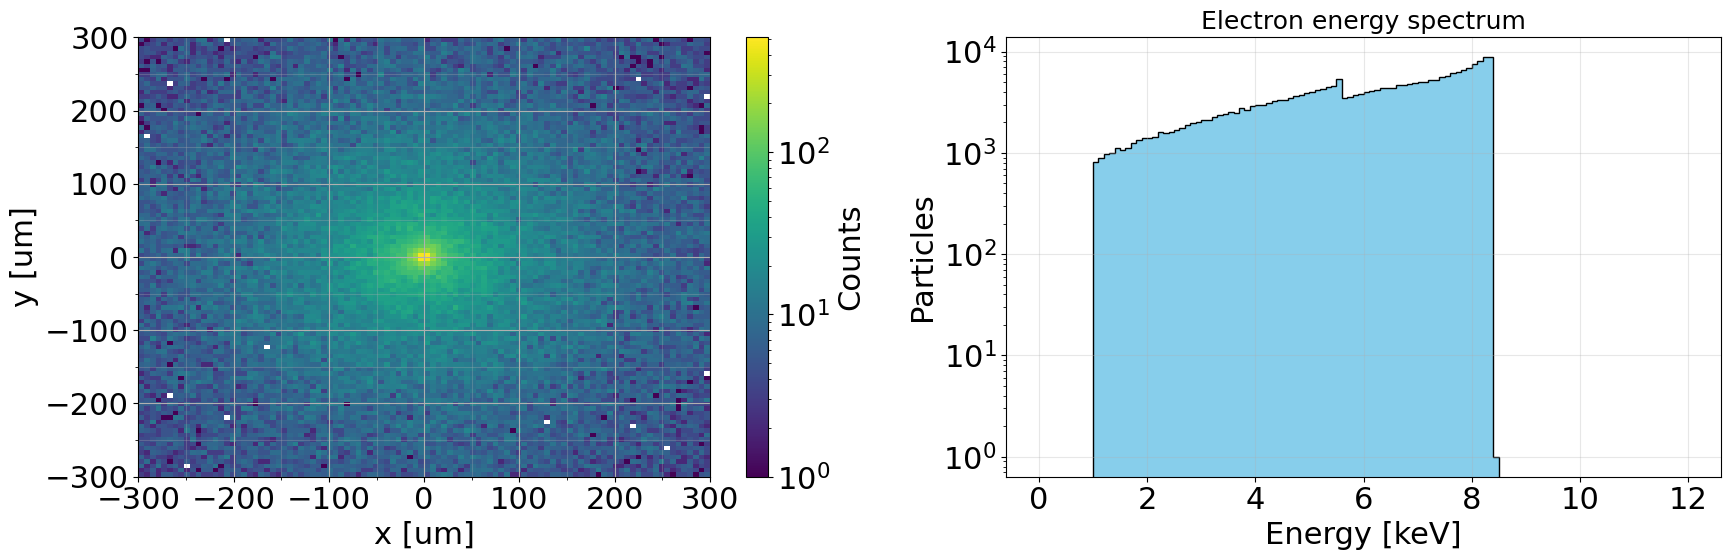

Number of particles = 262955


In [39]:
# Electrons
getRootDataAirElectrons('Pol01/build-10cm-electrons-noKapton/compton.root', 
                save_filename='xray_Primaries2.1e9_50um-NoKapton_1mAir_electrons',
                particle_id = 5,
                nPrimaries=2.100e9)

In [8]:
# Open the ROOT file
file = uproot.open("Pol01/build/xray_Primaries1e7_50umKapton_Vacuum.root")

In [9]:
# Access the 'Gamma' ntuple (usually under "Gamma" or "ntuple" inside the file)
# List all keys to be sure
print("Available keys:", file.keys())

# Access the TTree for Gamma
gamma_tree = file["Gamma;1"]  # If needed, replace with actual name from file.keys()

# Load the x, y, energy arrays
x = gamma_tree["x"].array(library="np")
y = gamma_tree["y"].array(library="np")
energy = gamma_tree["energy"].array(library="np")

# Convert x, y from mm to micrometers
x_um = x
y_um = y

Available keys: ['Gamma;1', 'Electrons;1', 'Positrons;1', 'h1;1', 'h2;1', 'h3;1', 'h4;1', 'h5;1', 'h6;1', 'h7;1', 'h8;1', 'h9;1', 'h10;1', 'h11;1', 'h12;1', 'h2d;3', 'h2d;2', 'h2d;1']


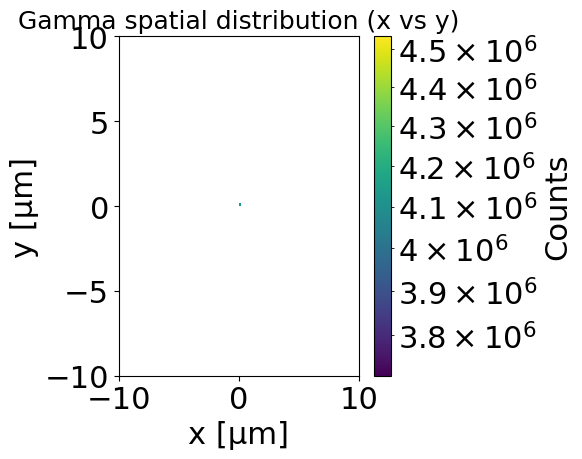

In [10]:
# 1. 2D Histogram of x vs y in [-100 µm, 100 µm]
plt.figure(figsize=(6, 5))
plt.hist2d(x_um, y_um, bins=100, range=[[-10, 10], [-10, 10]], cmap="viridis", norm=LogNorm())
plt.colorbar(label="Counts")
plt.xlabel("x [µm]")
plt.ylabel("y [µm]")
plt.title("Gamma spatial distribution (x vs y)")
plt.tight_layout()
plt.show()

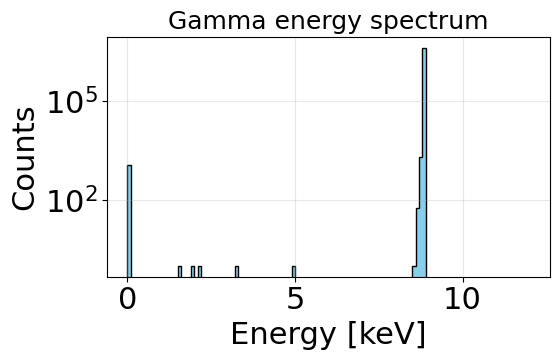

In [11]:
# 2. 1D Histogram of energy
plt.figure(figsize=(6, 4))
plt.hist(energy, bins=120, range=(0, 12), histtype='stepfilled', color='skyblue', edgecolor='black')
plt.xlabel("Energy [keV]")
plt.yscale('log')
plt.ylabel("Counts")
plt.title("Gamma energy spectrum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()